In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded!")

Libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()  # upload your feeds.csv here

df = pd.read_csv('feeds.csv')
df = df[['created_at', 'field1', 'field2', 'field3']]
df.columns = ['timestamp', 'vibration', 'current', 'temperature']
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.dropna()
df['vibration'] = df['vibration'].astype(int)
print(df.head(10))
print(f"\nTotal readings: {len(df)}")

Saving feeds.csv to feeds.csv
                  timestamp  vibration  current  temperature
0 2026-04-23 19:00:52+00:00          0     0.17        28.82
1 2026-04-23 19:01:08+00:00          0     0.20        29.09
2 2026-04-23 19:01:24+00:00          0     0.20        29.35
3 2026-04-23 19:01:40+00:00          0     0.18        29.95
4 2026-04-23 19:01:56+00:00          0     0.17        30.30
5 2026-04-23 19:02:12+00:00          0     0.18        30.47
6 2026-04-23 19:02:28+00:00          0     0.17        30.57
7 2026-04-23 19:02:44+00:00          0     0.20        30.87
8 2026-04-23 19:03:00+00:00          0     0.19        31.46
9 2026-04-23 19:03:16+00:00          0     0.18        31.51

Total readings: 42


In [3]:
def label_fault(idx):
    if idx <= 10:
        return 'Normal'
    elif idx <= 20:
        return 'Early_Fault'
    elif idx <= 30:
        return 'Developing_Fault'
    else:
        return 'Critical_Fault'

df['fault_stage'] = [label_fault(i+1) for i in range(len(df))]
print(df['fault_stage'].value_counts())

fault_stage
Critical_Fault      12
Normal              10
Early_Fault         10
Developing_Fault    10
Name: count, dtype: int64


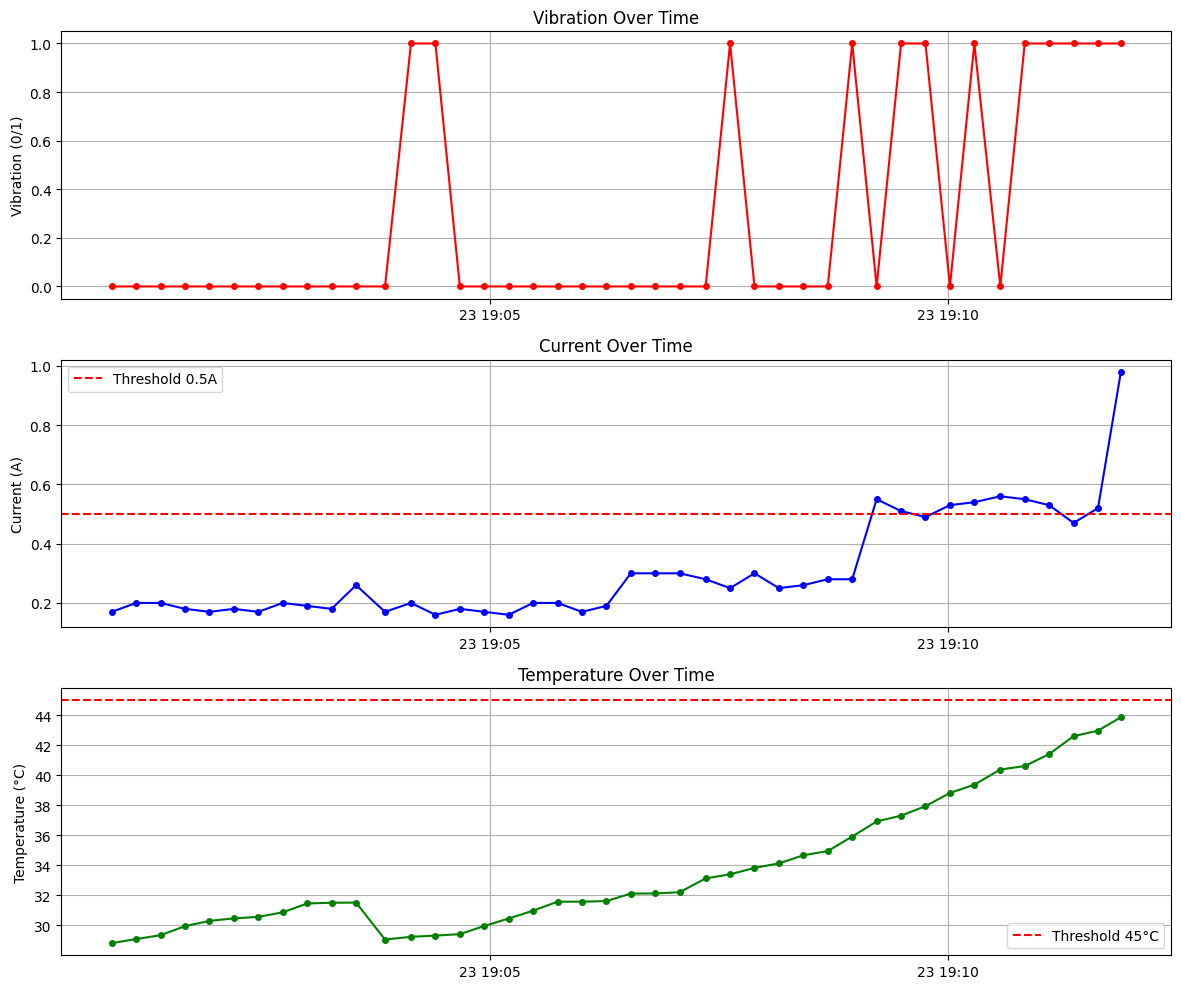

Saved: sensor_trends.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(df['timestamp'], df['vibration'], 'r-o', markersize=4)
axes[0].set_title('Vibration Over Time')
axes[0].set_ylabel('Vibration (0/1)')
axes[0].grid(True)

axes[1].plot(df['timestamp'], df['current'], 'b-o', markersize=4)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Threshold 0.5A')
axes[1].set_title('Current Over Time')
axes[1].set_ylabel('Current (A)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df['timestamp'], df['temperature'], 'g-o', markersize=4)
axes[2].axhline(y=45, color='red', linestyle='--', label='Threshold 45°C')
axes[2].set_title('Temperature Over Time')
axes[2].set_ylabel('Temperature (°C)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('sensor_trends.png', dpi=150)
plt.show()
print("Saved: sensor_trends.png")

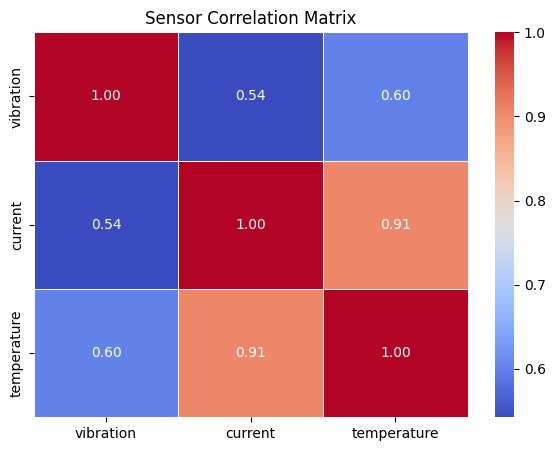


Correlation with Temperature:
vibration      0.600083
current        0.906857
temperature    1.000000
Name: temperature, dtype: float64


In [5]:
corr = df[['vibration', 'current', 'temperature']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Sensor Correlation Matrix')
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

print("\nCorrelation with Temperature:")
print(corr['temperature'])

In [7]:
# Add rolling features to help the model understand trends
df['current_rolling_mean'] = df['current'].rolling(window=3, min_periods=1).mean()
df['temp_rolling_mean'] = df['temperature'].rolling(window=3, min_periods=1).mean()
df['current_diff'] = df['current'].diff().fillna(0)
df['temp_diff'] = df['temperature'].diff().fillna(0)

print("New features added:")
print(df[['current', 'current_rolling_mean', 'current_diff', 'temperature', 'temp_rolling_mean', 'temp_diff']].head(10))

New features added:
   current  current_rolling_mean  current_diff  temperature  \
0     0.17              0.170000          0.00        28.82   
1     0.20              0.185000          0.03        29.09   
2     0.20              0.190000          0.00        29.35   
3     0.18              0.193333         -0.02        29.95   
4     0.17              0.183333         -0.01        30.30   
5     0.18              0.176667          0.01        30.47   
6     0.17              0.173333         -0.01        30.57   
7     0.20              0.183333          0.03        30.87   
8     0.19              0.186667         -0.01        31.46   
9     0.18              0.190000         -0.01        31.51   

   temp_rolling_mean  temp_diff  
0          28.820000       0.00  
1          28.955000       0.27  
2          29.086667       0.26  
3          29.463333       0.60  
4          29.866667       0.35  
5          30.240000       0.17  
6          30.446667       0.10  
7          30.

In [9]:
X = df[['vibration', 'current', 'temperature']]
y = df['fault_stage']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 77.8%

Classification Report:
                  precision    recall  f1-score   support

  Critical_Fault       1.00      1.00      1.00         3
Developing_Fault       1.00      1.00      1.00         2
     Early_Fault       0.00      0.00      0.00         2
          Normal       0.50      1.00      0.67         2

        accuracy                           0.78         9
       macro avg       0.62      0.75      0.67         9
    weighted avg       0.67      0.78      0.70         9



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


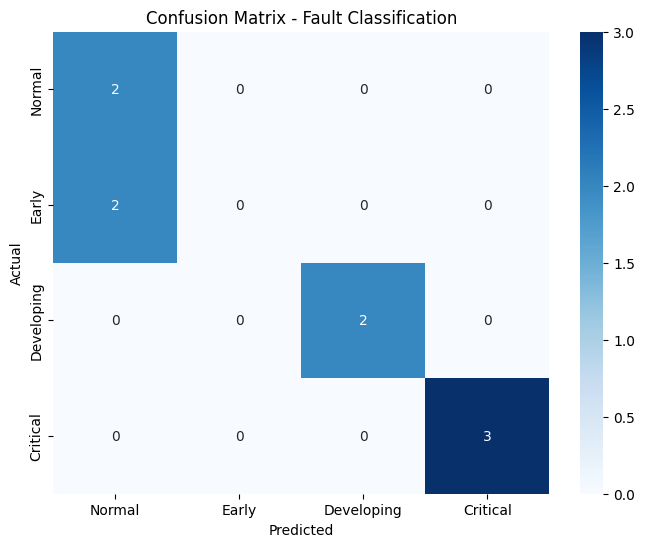

In [10]:
cm = confusion_matrix(y_test, y_pred,
     labels=['Normal','Early_Fault','Developing_Fault','Critical_Fault'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Early','Developing','Critical'],
            yticklabels=['Normal','Early','Developing','Critical'])
plt.title('Confusion Matrix - Fault Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

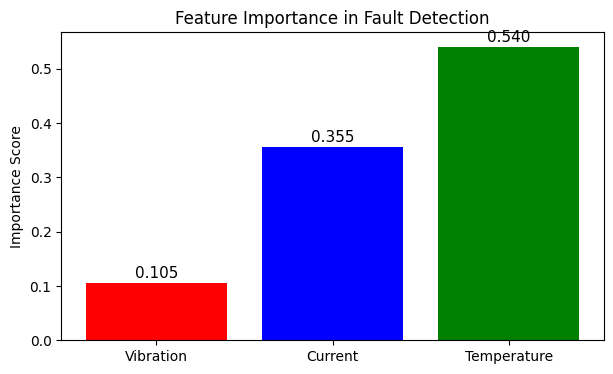


Most important sensor for fault detection:
Temperature (54.0%)


In [11]:
importance = model.feature_importances_
features = ['Vibration', 'Current', 'Temperature']

plt.figure(figsize=(7, 4))
bars = plt.bar(features, importance, color=['red', 'blue', 'green'])
plt.title('Feature Importance in Fault Detection')
plt.ylabel('Importance Score')
for bar, val in zip(bars, importance):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nMost important sensor for fault detection:")
print(f"{features[np.argmax(importance)]} ({max(importance)*100:.1f}%)")

In [12]:
files.download('sensor_trends.png')
files.download('correlation_matrix.png')
files.download('confusion_matrix.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>